## Data Preprocessing : Capping The Outliers

In [6]:
# Import Libaries required
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Reading Data From CSV
df = pd.read_csv(r'C:\Users\athar\Downloads\dataset.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [7]:
# Dataset Observation
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [17]:
# Dataset Observation , Number of Entries & Attributes
rows , columns = df.shape
print(f"Raw Dataset Contents {rows} entries and {columns} attributes")

Raw Dataset Contents 302 entries and 14 attributes


In [13]:
# Handling Null Values
print("Null Value in the Dataset are : \n")
df.isnull().sum()

Null Value in the Dataset are : 



age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [14]:
# Drop Duplicates
df = df.drop_duplicates()

In [16]:
# Dataset After Dropping Duplicates
rows , columns = df.shape
print(f"Raw Dataset Contents {rows} entries and {columns} attributes")

Raw Dataset Contents 302 entries and 14 attributes


In [18]:
# Dataset Before Capping the Outliers
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


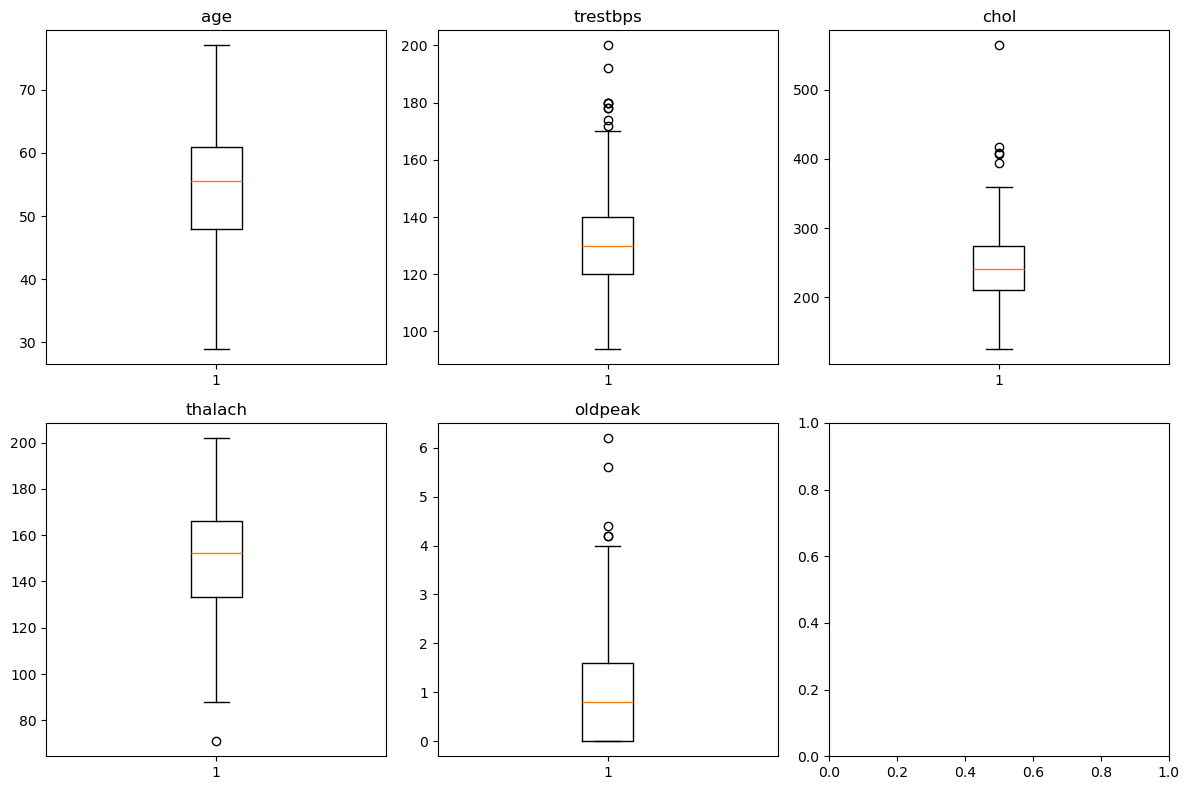

In [27]:
# Box plot for continous columns in dataset 
continuous_cols = ['age','trestbps','chol','thalach','oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

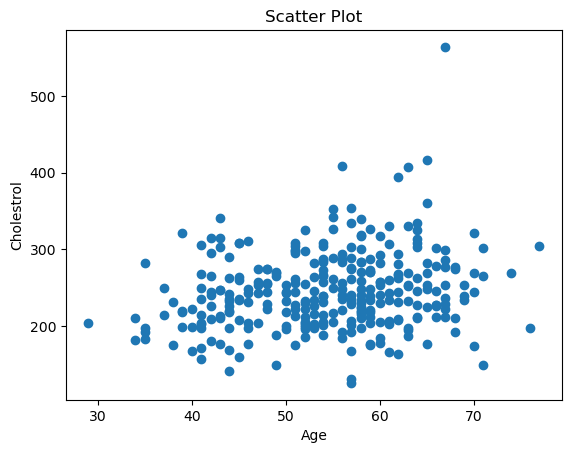

In [29]:
# Reationship between age and chesltrol before capping the outliers
plt.figure()
plt.scatter(df['age'], df['chol'])
plt.xlabel("Age")
plt.ylabel("Cholestrol")
plt.title("Scatter Plot")
plt.show()

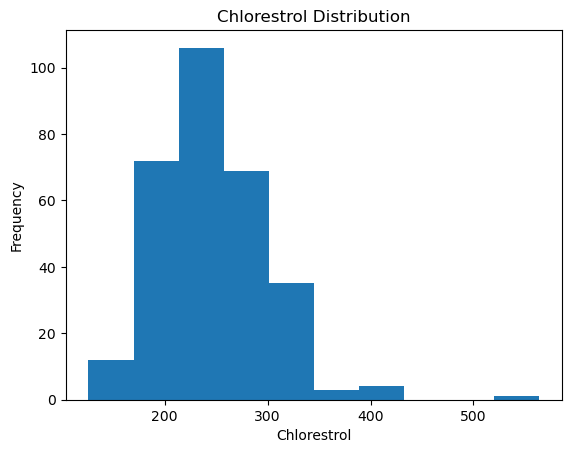

In [33]:
# Chlorestrol Distribution before capping the outliers
plt.hist(df['chol'])
plt.title("Chlorestrol Distribution")
plt.xlabel("Chlorestrol")
plt.ylabel("Frequency")
plt.show()

In [41]:
# Finding the 1st quartile & 3rd quartile and inter-quatertile range
q1 = df.quantile(0.25)
q3 = df.quantile(0.75)

# Calculating the Inter-quartile range
iqr = q3 - q1
print(f"Inter-Quartile Range: \n{iqr}")

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"\nLower Bound: \n{lower_bound}")
print(f"\nUpper Bound: \n{upper_bound}")

Inter-Quartile Range: 
age         13.00
sex          1.00
cp           2.00
trestbps    20.00
chol        63.75
fbs          0.00
restecg      1.00
thalach     32.75
exang        1.00
oldpeak      1.60
slope        1.00
ca           1.00
thal         1.00
target       1.00
dtype: float64

Lower Bound: 
age          28.500
sex          -1.500
cp           -3.000
trestbps     90.000
chol        115.375
fbs           0.000
restecg      -1.500
thalach      84.125
exang        -1.500
oldpeak      -2.400
slope        -0.500
ca           -1.500
thal          0.500
target       -1.500
dtype: float64

Upper Bound: 
age          80.500
sex           2.500
cp            5.000
trestbps    170.000
chol        370.375
fbs           0.000
restecg       2.500
thalach     215.125
exang         2.500
oldpeak       4.000
slope         3.500
ca            2.500
thal          4.500
target        2.500
dtype: float64


In [42]:
# Capping the outliers
new_df = df.clip(lower=lower_bound, upper=upper_bound, axis=1)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212.0,0,1,168.0,0,1.0,2,2.0,3.0,0
1,53,1,0,140,203.0,0,0,155.0,1,3.1,0,0.0,3.0,0
2,70,1,0,145,174.0,0,1,125.0,1,2.6,0,0.0,3.0,0
3,61,1,0,148,203.0,0,1,161.0,0,0.0,2,1.0,3.0,0
4,62,0,0,138,294.0,0,1,106.0,0,1.9,1,2.5,2.0,0
5,58,0,0,100,248.0,0,0,122.0,0,1.0,1,0.0,2.0,1
6,58,1,0,114,318.0,0,2,140.0,0,4.0,0,2.5,1.0,0
7,55,1,0,160,289.0,0,0,145.0,1,0.8,1,1.0,3.0,0
8,46,1,0,120,249.0,0,0,144.0,0,0.8,2,0.0,3.0,0
9,54,1,0,122,286.0,0,0,116.0,1,3.2,1,2.0,2.0,0


In [44]:
# Dataset After Capping the Outliers
new_df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212.0,0,1,168.0,0,1.0,2,2.0,3.0,0
1,53,1,0,140,203.0,0,0,155.0,1,3.1,0,0.0,3.0,0
2,70,1,0,145,174.0,0,1,125.0,1,2.6,0,0.0,3.0,0
3,61,1,0,148,203.0,0,1,161.0,0,0.0,2,1.0,3.0,0
4,62,0,0,138,294.0,0,1,106.0,0,1.9,1,2.5,2.0,0
5,58,0,0,100,248.0,0,0,122.0,0,1.0,1,0.0,2.0,1
6,58,1,0,114,318.0,0,2,140.0,0,4.0,0,2.5,1.0,0
7,55,1,0,160,289.0,0,0,145.0,1,0.8,1,1.0,3.0,0
8,46,1,0,120,249.0,0,0,144.0,0,0.8,2,0.0,3.0,0
9,54,1,0,122,286.0,0,0,116.0,1,3.2,1,2.0,2.0,0


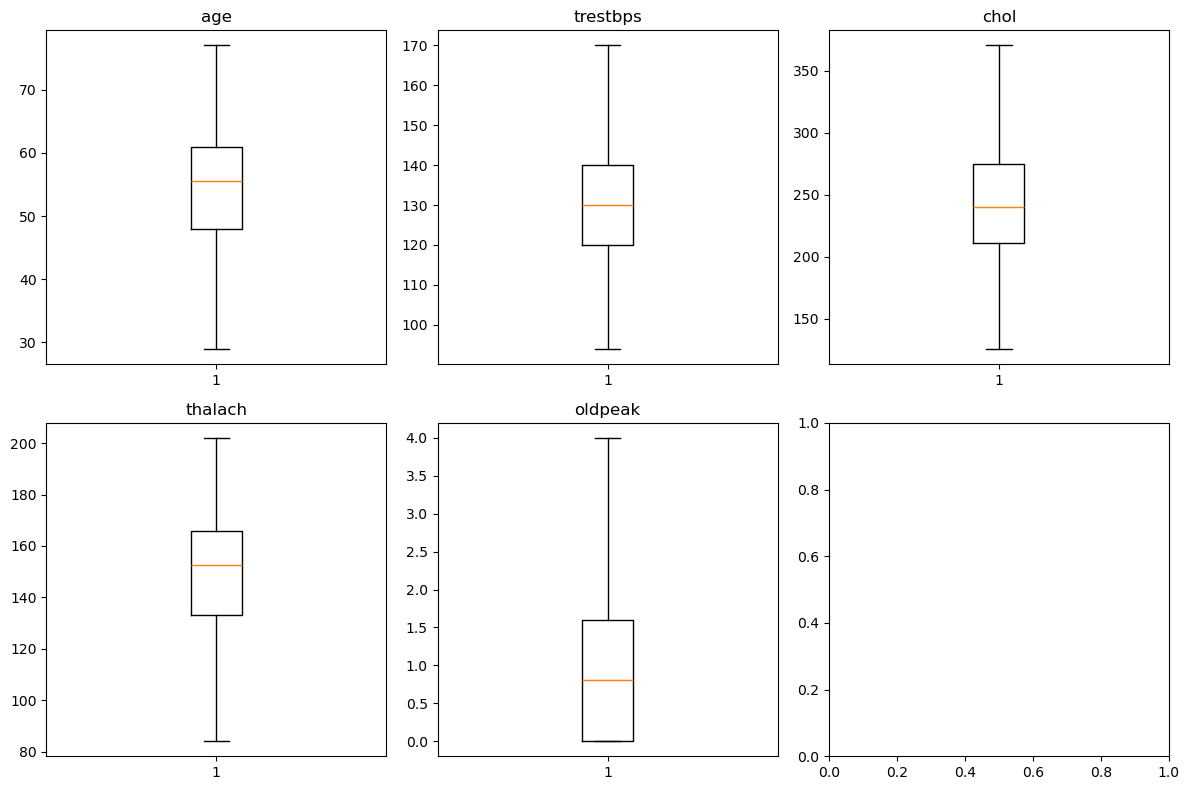

In [45]:
# Box plot for continous columns in dataset after capping the outlier
continuous_cols = ['age','trestbps','chol','thalach','oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].boxplot(new_df[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

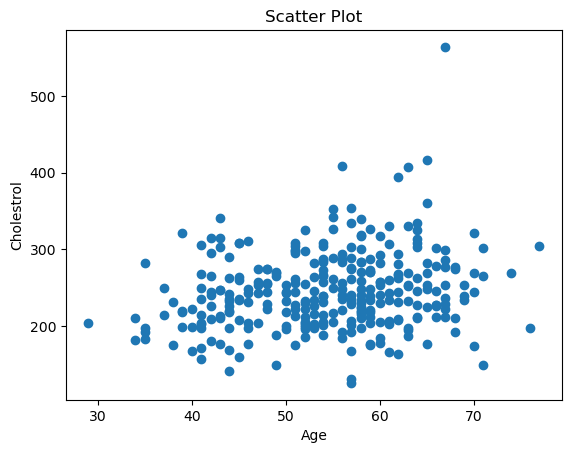

In [47]:
# Reationship between age and chesltrol after capping the outliers
plt.figure()
plt.scatter(new_df['age'], df['chol'])
plt.xlabel("Age")
plt.ylabel("Cholestrol")
plt.title("Scatter Plot")
plt.show()

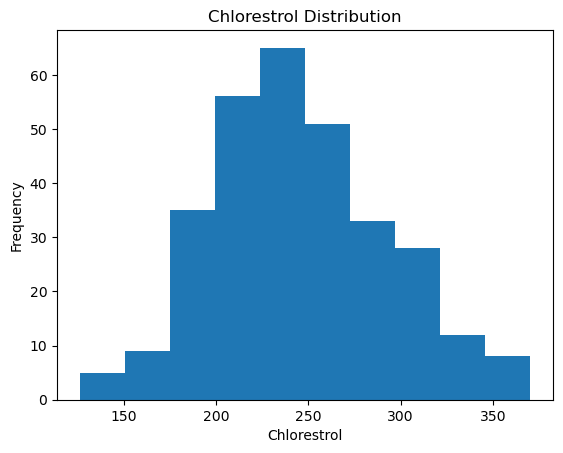

In [48]:
# Chlorestrol Distribution after capping the outliers
plt.hist(new_df['chol'])
plt.title("Chlorestrol Distribution")
plt.xlabel("Chlorestrol")
plt.ylabel("Frequency")
plt.show()

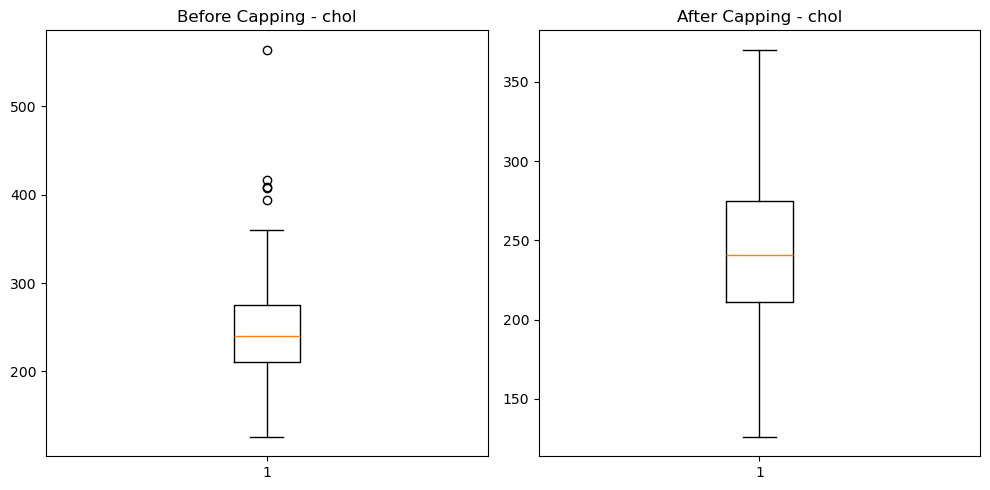

In [49]:
col = 'chol'   # change column name

fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].boxplot(df[col])
axes[0].set_title(f'Before Capping - {col}')

axes[1].boxplot(new_df[col])
axes[1].set_title(f'After Capping - {col}')

plt.tight_layout()
plt.show()

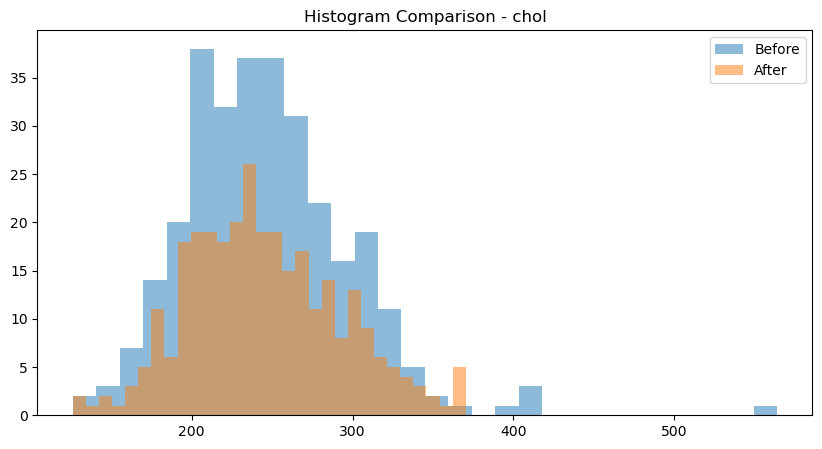

In [50]:
plt.figure(figsize=(10,5))

plt.hist(df[col], bins=30, alpha=0.5, label='Before')
plt.hist(new_df[col], bins=30, alpha=0.5, label='After')

plt.title(f'Histogram Comparison - {col}')
plt.legend()
plt.show()

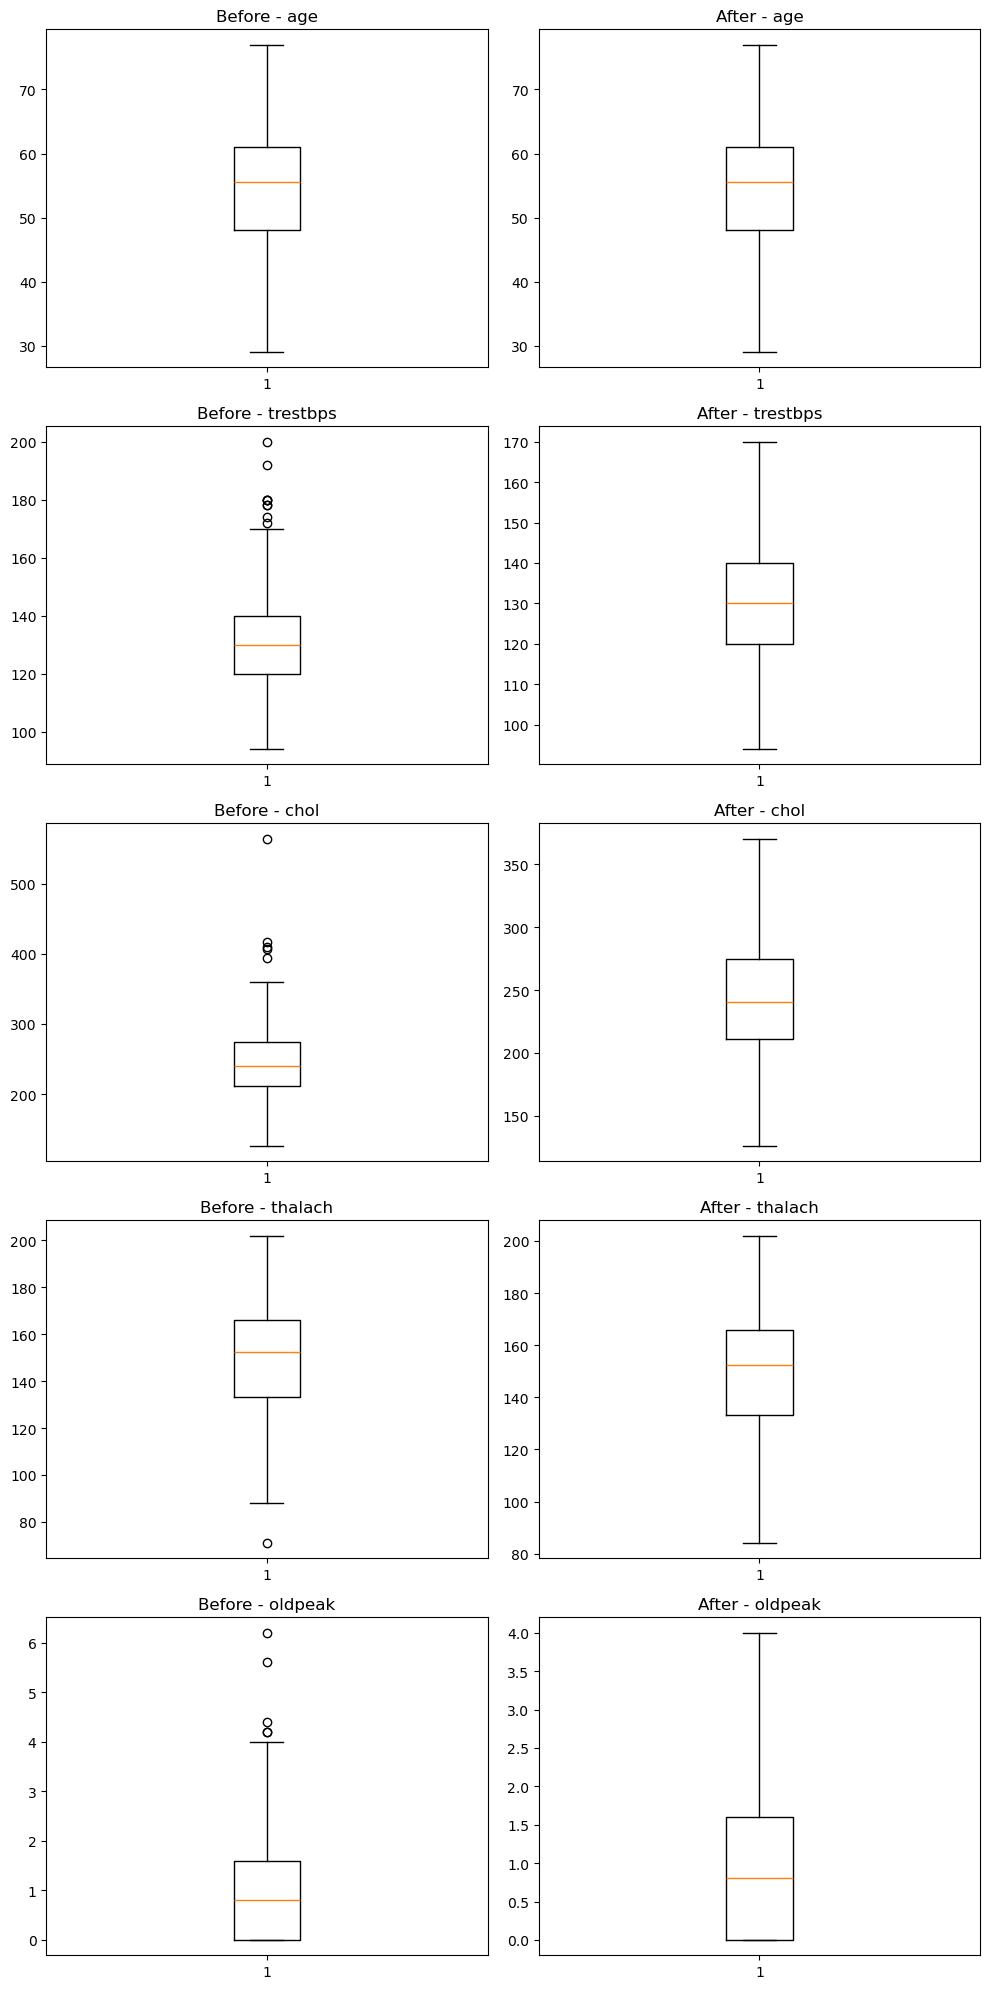

In [51]:
import math

cols = ['age','trestbps','chol','thalach','oldpeak']  # continuous only

n_cols = 2
n_rows = math.ceil(len(cols))

fig, axes = plt.subplots(len(cols), 2, figsize=(10, 4*len(cols)))

for i, col in enumerate(cols):
    axes[i,0].boxplot(df[col])
    axes[i,0].set_title(f'Before - {col}')
    
    axes[i,1].boxplot(new_df[col])
    axes[i,1].set_title(f'After - {col}')

plt.tight_layout()
plt.show()

In [52]:
print("Before max:\n", df.max())
print("After max:\n", new_df.max())

Before max:
 age          77.0
sex           1.0
cp            3.0
trestbps    200.0
chol        564.0
fbs           1.0
restecg       2.0
thalach     202.0
exang         1.0
oldpeak       6.2
slope         2.0
ca            4.0
thal          3.0
target        1.0
dtype: float64
After max:
 age          77.000
sex           1.000
cp            3.000
trestbps    170.000
chol        370.375
fbs           0.000
restecg       2.000
thalach     202.000
exang         1.000
oldpeak       4.000
slope         2.000
ca            2.500
thal          3.000
target        1.000
dtype: float64


In [53]:
print("Before describe:\n", df.describe())
print("After describe:\n", new_df.describe())

Before describe:
              age         sex          cp    trestbps        chol         fbs  \
count  302.00000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean    54.42053    0.682119    0.963576  131.602649  246.500000    0.149007   
std      9.04797    0.466426    1.032044   17.563394   51.753489    0.356686   
min     29.00000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     48.00000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.50000    1.000000    1.000000  130.000000  240.500000    0.000000   
75%     61.00000    1.000000    2.000000  140.000000  274.750000    0.000000   
max     77.00000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  302.000000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean     0.526490  149.569536    0.327815    1.043046    1.397351    0.718543   
std      0.526027 